## Shallow Autoencoders 

In [1]:
import os
import copy


import numpy as np
from numpy.core.fromnumeric import reshape

import tensorflow as tf
    
import keras
from keras import layers,Input,Sequential 
from keras.layers import Dense,Flatten,Reshape,Conv2DTranspose,Conv2D
from keras.models import Model


from keras.layers import Conv2D
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

C:\Users\BIT\AppData\Local\Temp\ipykernel_7412\3325631617.py:6: DeprecationWarning: numpy.core.fromnumeric is deprecated and has been renamed to numpy._core.fromnumeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.fromnumeric.reshape.
  from numpy.core.fromnumeric import reshape


In [2]:
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) =keras.datasets.mnist.load_data()


x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [3]:
input_img=Input(shape=(784,))

In [4]:
encoding_dim=36
encoder = Dense(encoding_dim, activation='relu')(input_img)

In [5]:
decoder=Dense(784,activation='sigmoid')(encoder)

In [6]:
autoencoder =Model(input_img, decoder)

In [7]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [8]:
history=autoencoder.fit(x_train, x_train,
                epochs=25,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2702 - val_loss: 0.1845
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1651 - val_loss: 0.1480
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1394 - val_loss: 0.1298
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1246 - val_loss: 0.1176
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1141 - val_loss: 0.1089
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1066 - val_loss: 0.1028
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1014 - val_loss: 0.0983
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0976 - val_loss: 0.0949
Epoch 9/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0947 - val_loss: 0.0924
Epoch 10/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0928 - val_loss: 0.0909
Epoch 11/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0916 - val_loss: 0.0899
Epoch 12/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

In [10]:
def graph_history(history, title='Log Loss and Accuracy over iterations'):
    
    fig = plt.figure(figsize=(16, 8))
    fig.suptitle(title)
    N_plots=len(history.history.keys())
    color_list=['b', 'r', 'g', 'c', 'm', 'y', 'k', 'w','bx','rx']
    for i,(key, items) in enumerate(history.history.items()):
        ax = fig.add_subplot(1, N_plots, i+1)
        ax.plot(items,c=color_list[i])
        ax.grid(True)
        ax.set(xlabel='iterations', title=key)

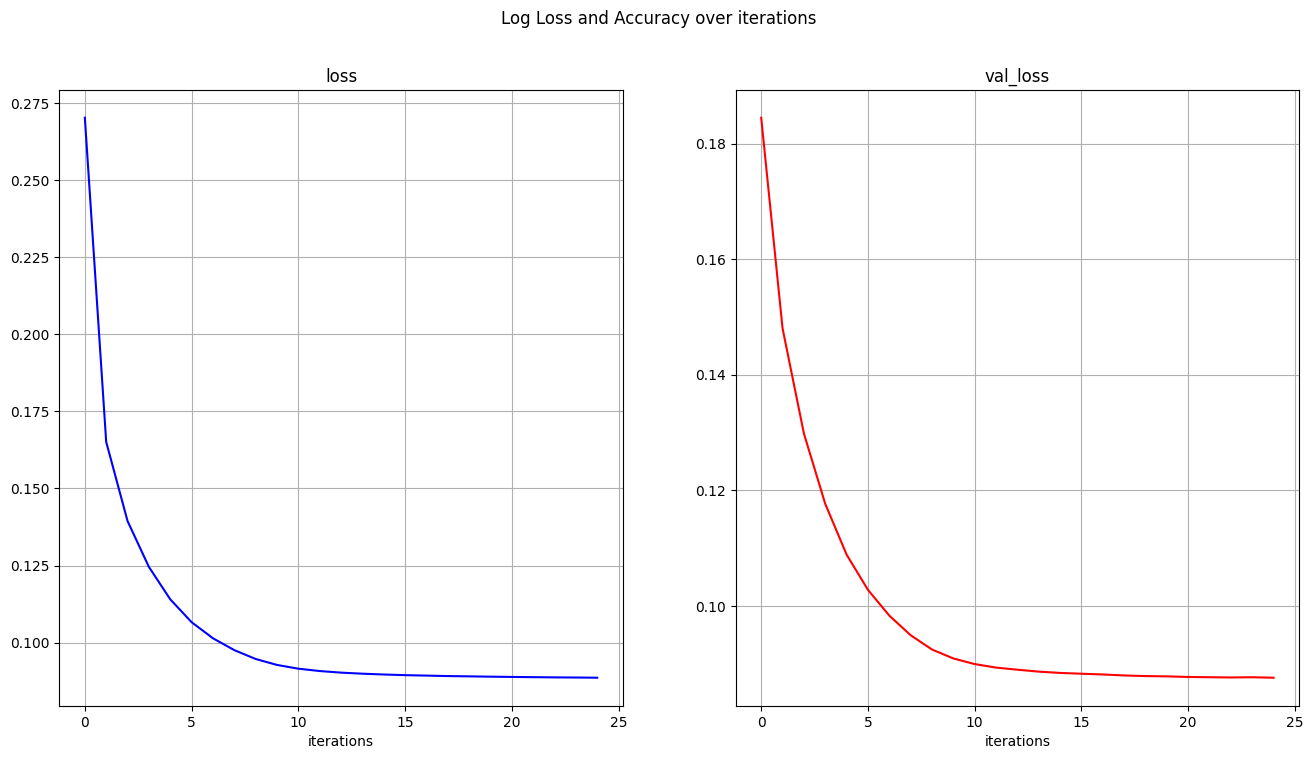

In [11]:
graph_history(history, title='Log Loss and Accuracy over iterations')

In [12]:
xhat=autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step


In [13]:
def plot_images(top,bottom,start=0,stop=5,reshape_x=(28,28),reshape_xhat=(28,28)):
    
    '''
    this function plots images from the start index to the stop index from two datasets
    
    '''

    n_samples=stop-start

    for i,img_index in enumerate(range(start,stop)):
        
        # Display original
        ax = plt.subplot(2, n_samples, i + 1)
        plt.imshow(top[img_index].reshape(reshape_x[0], reshape_x[1]), cmap="gray")

        if i==n_samples//2:
            plt.title("original images")

        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # Display reconstruction
        ax = plt.subplot(2, n_samples, i + 1 + n_samples)
        plt.imshow(bottom[img_index].reshape(reshape_xhat[0], reshape_xhat[1]), cmap="gray")


        if i==n_samples//2:
            plt.title("encoded images")

        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

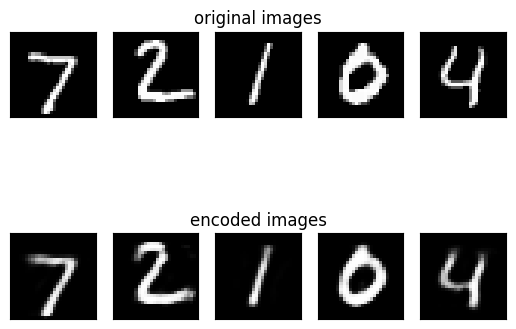

In [14]:
plot_images(x_test,xhat,start=0,stop=5)

### Autoencoders using Model Subclassing




In [16]:
class Autoencoder(tf.keras.Model):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim   
        self.encoder = Dense(latent_dim, activation='relu')
        self.decoder = Dense(784, activation='sigmoid')

    def call(self, x):
        
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [17]:
encoding_dim=36
autoencoder = Autoencoder(encoding_dim)

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.2719 - val_loss: 0.1875
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1659 - val_loss: 0.1483
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1397 - val_loss: 0.1298
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1244 - val_loss: 0.1172
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1139 - val_loss: 0.1085
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1067 - val_loss: 0.1026
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1015 - val_loss: 0.0983
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0978 - val_loss: 0.0952
Epoch 9/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0951 - val_loss: 0.0929
Epoch 10/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0931 - val_loss: 0.0913
Epoch 11/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0919 - val_loss: 0.0902
Epoch 12/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/st

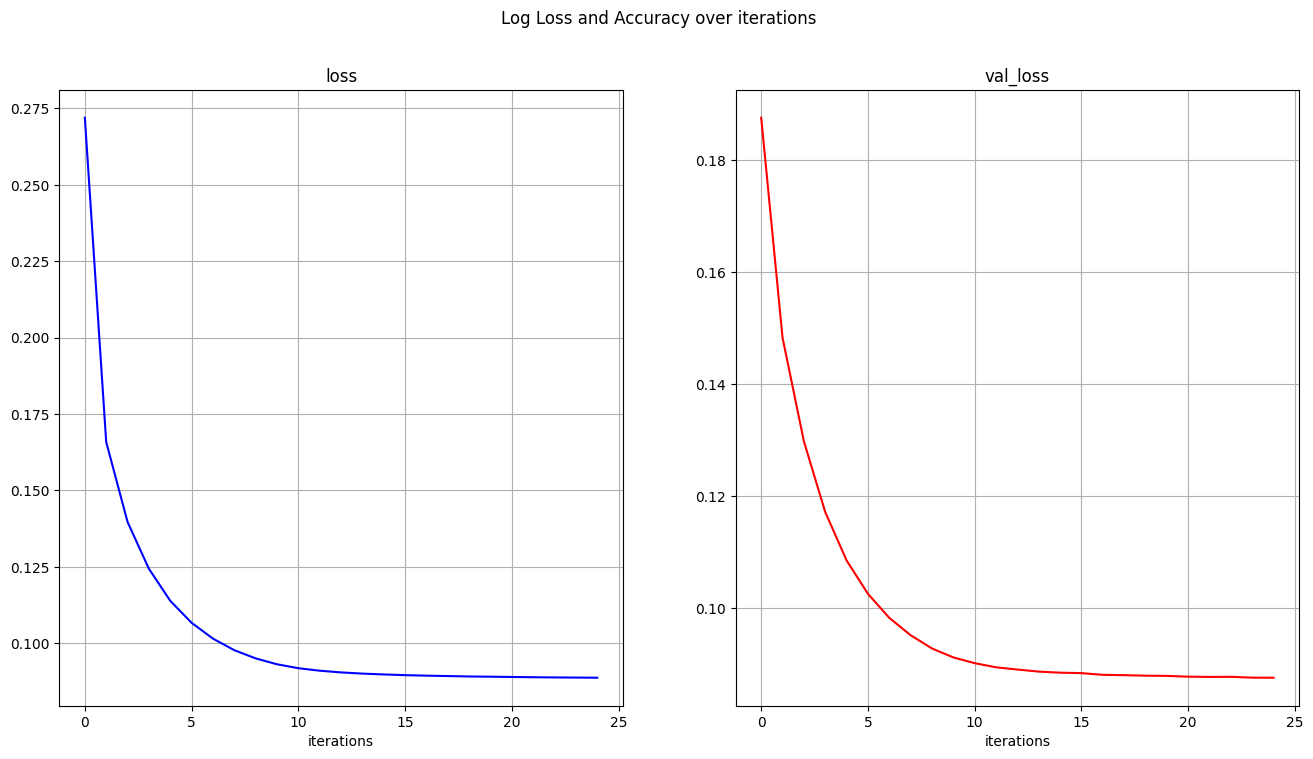

In [18]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
history=autoencoder.fit(x_train, x_train,epochs=25,batch_size=256,shuffle=True,validation_data=(x_test, x_test))
graph_history(history, title='Log Loss and Accuracy over iterations')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


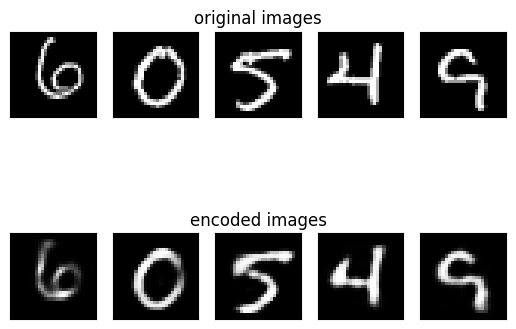

In [19]:
xhat=autoencoder.predict(x_test)
plot_images(x_test,xhat,start=100,stop=105)

In [21]:
h=autoencoder.encoder(x_test)
h.shape

TensorShape([10000, 36])

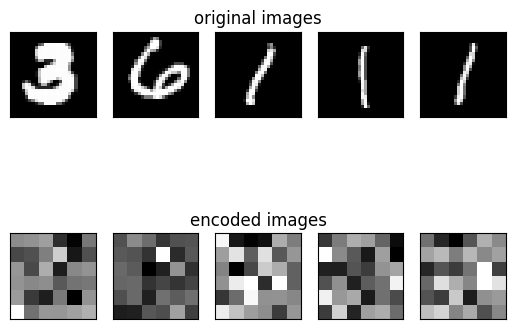

In [22]:
plot_images(x_test, h.numpy(),start=200,stop=205,reshape_x=(28,28),reshape_xhat=(6,6))

In [23]:
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [24]:
loss=[bce(x, x_s).numpy() for x, x_s in zip (x_test,xhat)]

In [27]:
def add_noise(x_train, x_test, noise_factor = 0.3):
    '''
    this function adds random values from a normal distribution as noises to the data 
    
    returns the noisy datasets 
    
    '''
    noise_factor = 0.3
    x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape) 
    x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape) 

    x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.).numpy()
    x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.).numpy()
    
    return x_train_noisy,x_test_noisy

In [28]:
x_train_noisy,x_test_noisy= add_noise(x_train, x_test,noise_factor = 0.4)

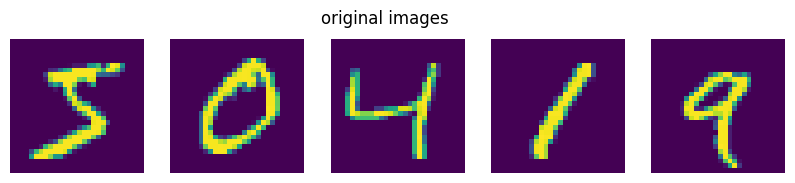

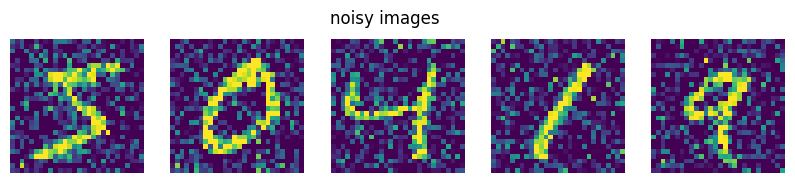

In [31]:
np.random.seed(42)
fig1 = plt.figure(figsize=(10,2))
fig1.suptitle("original images")
fig2 = plt.figure(figsize=(10,2))
fig2.suptitle("noisy images")

for i, img_index in enumerate(range(5)):
    ax1 = fig1.add_subplot(1, 5, i+1)
    ax1.imshow(x_train[img_index].reshape((28,28)))
    ax1.axis("off")
    ax2 = fig2.add_subplot(1, 5, i+1)
    ax2.imshow(x_train_noisy[img_index].reshape((28,28)))
    ax2.axis("off")

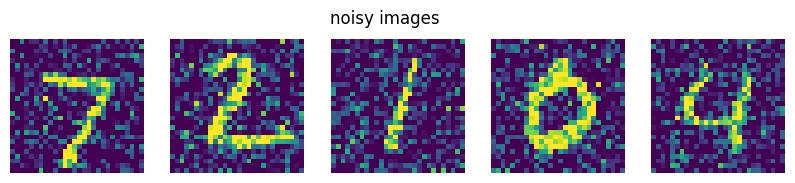

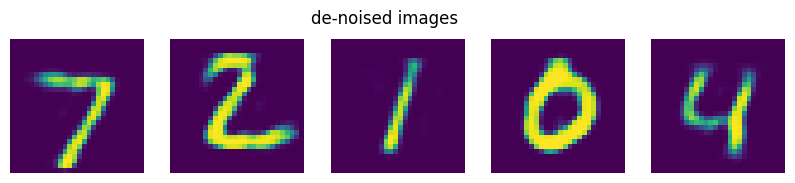

In [32]:
np.random.seed(42)
fig1 = plt.figure(figsize=(10,2))
fig1.suptitle("noisy images")
fig2 = plt.figure(figsize=(10,2))
fig2.suptitle("de-noised images")

for i, img_index in enumerate(range(5)):
    ax1 = fig1.add_subplot(1, 5, i+1)
    ax1.imshow(x_test_noisy[img_index].reshape((28,28)))
    ax1.axis("off")
    ax2 = fig2.add_subplot(1, 5, i+1)
    ax2.imshow(xhat[img_index].reshape((28,28)))
    ax2.axis("off")

In [33]:
x_train_flat = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test_flat = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train_flat.shape)
print(x_test_flat.shape)

(60000, 784)
(10000, 784)


In [34]:
from sklearn.preprocessing import MinMaxScaler
s = MinMaxScaler().fit(x_train_flat)
x_train_scaled = s.transform(x_train_flat)

In [35]:
from sklearn.decomposition import PCA

def mnist_pca(x_data, n_components):
    pca = PCA(n_components=n_components)

    fit_pca = pca.fit(x_data)
    
    print("Variance explained with {0} components:".format(n_components), 
          round(sum(fit_pca.explained_variance_ratio_), 2))

    return fit_pca, fit_pca.transform(x_data)

In [36]:
pca_full, mnist_data_full = mnist_pca(x_train_scaled, 784)

Variance explained with 784 components: 1.0


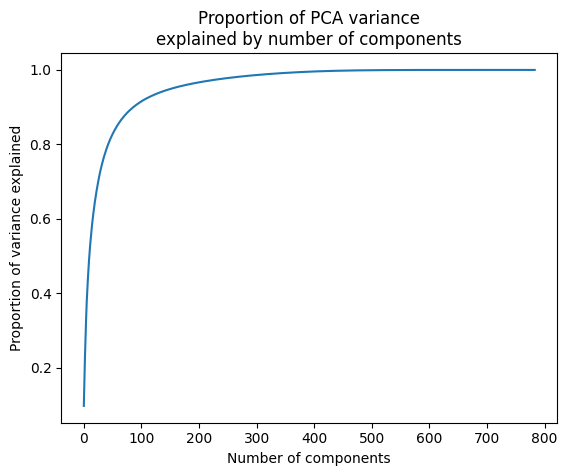

In [37]:
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.title("Proportion of PCA variance\nexplained by number of components")
plt.xlabel("Number of components")
plt.ylabel("Proportion of variance explained");

We need about 250 components to explain 90% of the variance in the data!


In [38]:
pca_2, mnist_data_2 = mnist_pca(x_train_scaled, 2)

Variance explained with 2 components: 0.17


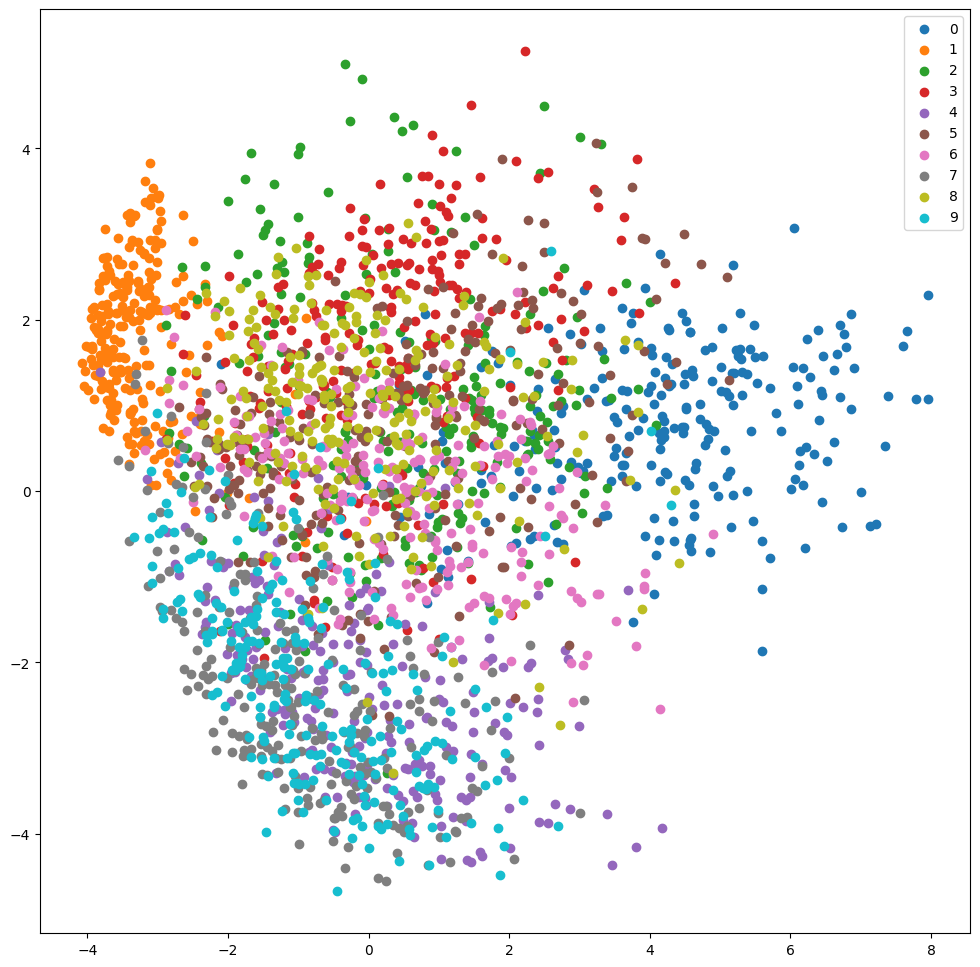

In [39]:
num_images_per_class = 250
fig = plt.figure(figsize=(12,12))
for number in list(range(10)):
    mask = y_train == number
    x_data = mnist_data_2[mask, 0][:num_images_per_class]
    y_data = mnist_data_2[mask, 1][:num_images_per_class]
    plt.scatter(x_data, y_data, label=number, alpha=1)
plt.legend();